# Targeted password guessing with prompt evolution and PassLLM

A pipeline for prompt evolution using OpenEvolve with Qwen3-8b as mutator and PassLLM Qwen2.5-0.5B with adapter as evaluator. For submission up to 100 password candidates are generated per test sample.

## Install dependencies

In [61]:
!pip install -q openevolve transformers peft accelerate pyyaml flask nest_asyncio

## Download competition data from Kaggle

Upload your `kaggle.json` API token when prompted.

In [1]:
import os
import sys


kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
src_config = 'kaggle.json'
dst_config = os.path.join(kaggle_dir, 'kaggle.json')

if os.path.exists(src_config):
    import shutil
    if os.path.abspath(src_config) != os.path.abspath(dst_config):
        shutil.copy(src_config, dst_config)
    
    if os.name != 'nt':
        os.chmod(dst_config, 0o600)
    print("Ok")
else:
    print('Error')


Ok


Make a content directory to process the data in Colab way.

In [2]:
!sudo mkdir -p /content/data
!sudo chmod 777 /content/data

In [3]:
!kaggle competitions download -c password-guessing -p /content/data
!unzip -q /content/data/password-guessing.zip -d /content/data

password-guessing.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/data/126_csdn_disQwen0.5B/126_csdn_disQwen0.5B/README.md? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


## Environment setup and constants

In [4]:
import multiprocessing
try:
    multiprocessing.set_start_method("spawn", force=True)
except RuntimeError:
    pass

import os
import json
from pathlib import Path

COMPETITION = "/content/data"
PATH_TRAIN = os.path.join(COMPETITION, "train.json")
PATH_ADAPTER_126_CSDN = os.path.join(COMPETITION, "126_csdn_disQwen0.5B", "126_csdn_disQwen0.5B")
BASE_MODEL_PASSLLM = "Qwen/Qwen2.5-0.5B-Instruct"

EXPERIMENT_DIR = os.path.join(os.getcwd(), "targeted_evolution_exp")
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

os.environ["PASSLLM_COMPETITION"] = COMPETITION
os.environ["PASSLLM_TRAIN"] = PATH_TRAIN
os.environ["PASSLLM_ADAPTER_126_CSDN"] = PATH_ADAPTER_126_CSDN
os.environ["PASSLLM_BASE_MODEL"] = BASE_MODEL_PASSLLM
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print("COMPETITION:", COMPETITION)
print("PATH_TRAIN:", PATH_TRAIN)
print("PATH_ADAPTER_126_CSDN:", PATH_ADAPTER_126_CSDN)
print("EXPERIMENT_DIR:", EXPERIMENT_DIR)

COMPETITION: /content/data
PATH_TRAIN: /content/data/train.json
PATH_ADAPTER_126_CSDN: /content/data/126_csdn_disQwen0.5B/126_csdn_disQwen0.5B
EXPERIMENT_DIR: /home/coder/project/jupyter/targeted_evolution_exp


In [5]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

CUDA available: True
Device: NVIDIA GeForce RTX 4090


In [6]:
with open(PATH_TRAIN, "r", encoding="utf-8") as f:
    TRAIN_DATA = json.load(f)
if isinstance(TRAIN_DATA, dict):
    TRAIN_DATA = [TRAIN_DATA]
print("Train samples:", len(TRAIN_DATA))
if TRAIN_DATA:
    print("Example:", TRAIN_DATA[0])

Train samples: 16000
Example: {'Knowledge': {'Old password': '225654314'}, 'password': '225654314'}


## Password length distribution

Total passwords: 16000
Mean length: 8.84
Std dev: 2.73
1 sigma interval: [6.11, 11.57]
2 sigma interval: [3.38, 14.31]


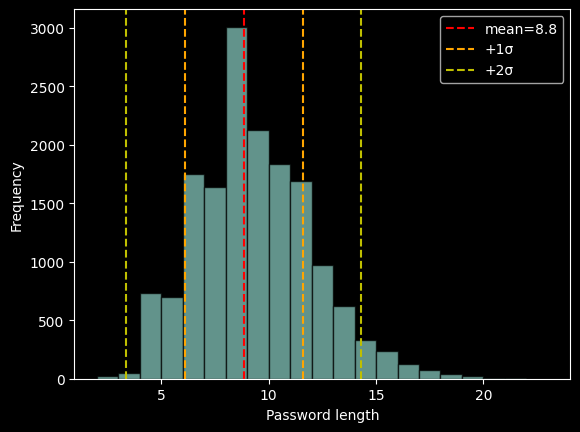

In [7]:
import numpy as np
import matplotlib.pyplot as plt

lengths = []
for item in TRAIN_DATA:
    pwd = item.get("password")
    if pwd and isinstance(pwd, str):
        lengths.append(len(pwd))

lengths = np.array(lengths)
mean = np.mean(lengths)
std = np.std(lengths)

print(f"Total passwords: {len(lengths)}")
print(f"Mean length: {mean:.2f}")
print(f"Std dev: {std:.2f}")
print(f"1 sigma interval: [{mean-std:.2f}, {mean+std:.2f}]")
print(f"2 sigma interval: [{mean-2*std:.2f}, {mean+2*std:.2f}]")

plt.hist(lengths, bins=21, alpha=0.7, edgecolor='black')
plt.axvline(mean, color='r', linestyle='dashed', label=f'mean={mean:.1f}')
plt.axvline(mean+std, color='orange', linestyle='dashed', label='+1σ')
plt.axvline(mean-std, color='orange', linestyle='dashed')
plt.axvline(mean+2*std, color='y', linestyle='dashed', label='+2σ')
plt.axvline(mean-2*std, color='y', linestyle='dashed')
plt.xlabel("Password length")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Evolution configuration and initial prompt

In [8]:
CONFIG_YAML = '''
llm:
  models:
    - name: openai/gpt-oss-120b
      api_base: https://api.zveno.ai/v1
      api_key: API_TOKEN
      api_type: openai
      default_params:
        temperature: 1.0
        top_p: 0.95
        max_tokens: 10000
        presence_penalty: 0.5

evolution:
  generations: 10
  population_size: 8
  elitism: 2

operators:
  mutation:
    type: llm
    llm_model: openai/gpt-oss-120b
    prompt_template: |
      You are improving a prompt for **trawling password guessing**.
      The current prompt is:
      """{program}"""
      Its performance (cracked rate) on training data is {score:.4f}.
      Analyze its weaknesses. How can it be improved to guess a WIDER VARIETY of passwords?
      Focus on increasing **diversity** and **coverage** of password patterns.
      Be creative: add new instructions, rephrase, or include examples.
      Output only the new prompt text, nothing else.
  crossover:
    type: llm
    llm_model: openai/gpt-oss-120b
    probability: 0.7
    prompt_template: |
      You are an expert in password guessing.
      Your task is to create a NEW, SUPERIOR prompt by combining the strengths of two existing ones.
      Your goal is to MAXIMIZE the cracking rate on a training set.
      Be creative. Synthesize the best parts of Prompt A and Prompt B.
      Return ONLY the new prompt text, no explanations.

      Prompt A (Score: {score_a:.4f}): """{program_a}"""
      Prompt B (Score: {score_b:.4f}): """{program_b}"""

      New, combined prompt:

selection:
  type: tournament
  tournament_size: 3
'''

config_path = os.path.join(EXPERIMENT_DIR, "config_targeted_qwen3_8b.yaml")
with open(config_path, "w", encoding="utf-8") as f:
    f.write(CONFIG_YAML.strip())
print("Config written:", config_path)

Config written: /home/coder/project/jupyter/targeted_evolution_exp/config_targeted_qwen3_8b.yaml


In [9]:
INITIAL_PROMPT_TARGETED = """You are a targeted password guessing model. Your task: given an old password, generate a single realistic new password that a human might choose.

Consider the following common human password creation patterns:
- Length 6-12 characters, most often 9.
- Mix of lowercase, uppercase, digits, and symbols (!@#$%&*).
- Leet substitutions: P@ssw0rd, Tr0ub4dor, 5ecr3t, L3tme1n, G0Dzilla.
- Dates: MMDDYYYY, DDMMYYYY, YYYYMMDD, MMDDYY, YYMMDD (with or without separators), years 1970-2005, 2020-2024, repeating years (1111,2222).
- Names: common first/last names, pet names, nicknames.
- Keyboard walks: horizontal (asdf, zxcv), diagonal (qweasd, 1qaz2wsx), spatial repeats (jjjj, kkkk).
- Base words: password, pass, admin, welcome, login, user, account, master, shadow, super, access.
- Number patterns: 123456, 654321, 1111, 9999, 0000, 1313, 6969.
- Frequent combinations: Word+Number (Apple123), Word+Symbol+Number (Sony#88), Name+BirthYear (Jessica1987), Word+Leet+Date (P@ss1990), KeyboardPattern+Number (qwerty123).
- Cultural references: games (Minecraft, Fortnite), movies (StarWars, Avengers), sports (Lakers, United), music (Beatles, Metallica).

Example: Old password "password123" -> New password "P@ssw0rd2024"

Now, generate the new password. Output **only** the password string. Do not include any explanations, notes, or extra text. Just the password."""

initial_prompt_path = os.path.join(EXPERIMENT_DIR, "initial_prompt.txt")
with open(initial_prompt_path, "w", encoding="utf-8") as f:
    f.write(INITIAL_PROMPT_TARGETED)
print("Initial prompt (targeted) written:", initial_prompt_path)

Initial prompt (targeted) written: /home/coder/project/jupyter/targeted_evolution_exp/initial_prompt.txt


## Unified core module `passllm_core.py`

Model loading, candidate generation, and crack rate evaluation logic. For each password, we generate N_expected (e.g., 100) * 1.5 parallel versions and choose only unique ones. If the number of unique ones is less than N_expected, we just fill it with Old_password + random_symbol combinations.

In [11]:
%%writefile passllm_core.py
import os
import json
import torch
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

def load_model():
    base_model_name = os.environ.get("PASSLLM_BASE_MODEL", "Qwen/Qwen2.5-0.5B-Instruct")
    adapter_path = os.environ.get("PASSLLM_ADAPTER_126_CSDN", "")
    tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
    tokenizer.pad_token_id = tokenizer.eos_token_id

    if torch.cuda.is_available():
        print("Device in load_model():", torch.cuda.get_device_name(0))
    else:
        print('CPU run')
    model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        device_map="auto",
        torch_dtype=torch.bfloat16,
        trust_remote_code=True,
    )

    if adapter_path and os.path.exists(adapter_path):
        print(f"[INFO] Loading adapter from {adapter_path}")
        model = PeftModel.from_pretrained(model, adapter_path, is_trainable=False)
        model = model.merge_and_unload()
        print("[INFO] Adapter loaded and merged successfully.")
    else:
        print(f"[WARNING] Adapter path not found: {adapter_path}. Using base model only.")

    model.eval()
    
    return model, tokenizer

def generate_candidates(old_password, prompt_template, model, tokenizer,
                        target_count=100, gen_multiplier=1.5, verbose=False):
    generation_count = int(target_count * gen_multiplier)
    knowledge = json.dumps({"Old password": old_password})
    full_input = prompt_template.strip() + "\n" + knowledge + "\nPassword:"
    inputs = tokenizer(full_input, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=32,
            do_sample=True,
            temperature=0.9,
            top_p=0.95,
            num_return_sequences=generation_count,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    candidates = []
    for out in outputs:
        generated_text = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        guess = generated_text.split("\n")[0].strip()
        if guess.lower().startswith("password:"):
            guess = guess[9:].strip()
        if guess:
            candidates.append(guess[:64])
    unique_candidates = []
    seen = set()
    for c in candidates:
        if c not in seen:
            seen.add(c)
            unique_candidates.append(c)
        if len(unique_candidates) == target_count:
            break
    if len(unique_candidates) < target_count:
        import random
        import string
        chars = string.ascii_letters + string.digits + "!@#$%&*"
        for _ in range(target_count - len(unique_candidates)):
            unique_candidates.append(old_password + random.choice(chars))
    return unique_candidates

def compute_crack_rate(valid_items, prompt_template, model, tokenizer,
                       sample_size=100, num_candidates=20, gen_multiplier=1.5):
    indices = torch.randperm(len(valid_items))[:sample_size].tolist()
    sample_items = [valid_items[i] for i in indices]
    correct = 0
    total = 0
    for item in tqdm(sample_items, desc="Evaluating Crack Rate"):
        old = (item.get("Knowledge") or {}).get("Old password")
        target = item.get("password")
        if not old or not target:
            continue
        total += 1
        candidates = generate_candidates(old, prompt_template, model, tokenizer,
                                         target_count=num_candidates, gen_multiplier=gen_multiplier)
        if target in candidates:
            correct += 1
    rate = correct / total if total > 0 else 0.0
    print(f"Evaluation complete: {correct}/{total} correct. Crack Rate: {rate:.4f}")
    return rate


Overwriting passllm_core.py


## Evaluator for OpenEvolve

This script is called by the evolution framework. It imports the core module and implements the required `evaluate(program)` function.

In [12]:
%%writefile evaluator.py
import os
import sys
import json
import torch
sys.path.append(os.getcwd())
from passllm_core import load_model, compute_crack_rate

PATH_TRAIN = os.environ.get("PASSLLM_TRAIN", "")
if not PATH_TRAIN:
    print("Error: PASSLLM_TRAIN environment variable not set.", file=sys.stderr)
    sys.exit(1)

SAMPLE_SIZE = int(os.environ.get("PASSLLM_EVAL_SAMPLE_SIZE", "100"))
NUM_CANDIDATES = int(os.environ.get("PASSLLM_EVAL_NUM_CANDIDATES", "10"))
GEN_MULTIPLIER = float(os.environ.get("PASSLLM_EVAL_GEN_MULTIPLIER", "1.5"))

MODEL, TOKENIZER = load_model()

def evaluate(program: str) -> dict:
    try:
        with open(PATH_TRAIN, "r", encoding="utf-8") as f:
            train_data = json.load(f)
        if isinstance(train_data, dict):
            train_data = [train_data]
        valid_items = []
        for item in train_data:
            old = (item.get("Knowledge") or {}).get("Old password")
            target = item.get("password")
            if old and target:
                valid_items.append(item)
        sample_size = min(SAMPLE_SIZE, len(valid_items))
        crack_rate = compute_crack_rate(
            valid_items,
            program,
            MODEL,
            TOKENIZER,
            sample_size=sample_size,
            num_candidates=NUM_CANDIDATES,
            gen_multiplier=GEN_MULTIPLIER
        )
        return {"combined_score": crack_rate}
    except Exception as e:
        print(f"Evaluation failed: {e}", file=sys.stderr)
        return {"combined_score": 0.0}

Overwriting evaluator.py


In [14]:
os.environ["PASSLLM_EVAL_SAMPLE_SIZE"] = "200"
os.environ["PASSLLM_EVAL_NUM_CANDIDATES"] = "10"
os.environ["PASSLLM_EVAL_GEN_MULTIPLIER"] = "1.2"

## LLM provider 1. Setup Ollama and Qwen3-8b as mutator

Install system dependencies and run the Ollama server. Alternatively, we will use LLM APIs by ZvenoAI. They are cheap enough (a full run costs no more than 10 rubles) and provide models with 100B+ parameters.

In [ ]:
!apt-get update -qq && apt-get install -y -qq zstd

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package zstd.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
import subprocess, shutil, time, urllib.request, threading

def run_ollama_serve():
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = "0"
    env["OLLAMA_HOST"] = "127.0.0.1:11434"
    subprocess.run(["ollama", "serve"], env=env, check=False)

if not (os.path.exists("/usr/local/bin/ollama") or shutil.which("ollama")):
    !curl -fsSL https://ollama.com/install.sh | sh
else:
    print("Ollama already installed")

ollama_bin = shutil.which("ollama") or ("/usr/local/bin/ollama" if os.path.exists("/usr/local/bin/ollama") else None)
if not ollama_bin:
    raise RuntimeError("Ollama install failed: binary not found. Install system zstd first (apt-get install zstd), then re-run this cell.")

server_thread = threading.Thread(target=run_ollama_serve, daemon=True)
server_thread.start()
time.sleep(3)

In [ ]:
!ollama pull qwen3:8b

In [ ]:
for _ in range(60):
    try:
        r = urllib.request.urlopen(urllib.request.Request("http://127.0.0.1:11434/v1/models", method="GET"), timeout=5)
        if r.status == 200:
            print("Ollama API ready: http://127.0.0.1:11434/v1")
            break
    except Exception:
        time.sleep(2)
else:
    raise RuntimeError("Ollama did not respond in time")

Ollama API ready: http://127.0.0.1:11434/v1


A simple inference example.

In [ ]:
import requests
import json

url = "http://127.0.0.1:11434/api/generate"
payload = {
    "model": "qwen3:8b",
    "prompt": "Do you know how to write code that will be used for password cracking?",
    "stream": False,
    "options": {
        "temperature": 0.7,
        "top_p": 0.95
    }
}

response = requests.post(url, json=payload)
if response.status_code == 200:
    answer = response.json().get("response", "")
    print("Qwen3-8b response:\n", answer)
else:
    print(f"Error {response.status_code}: {response.text}")

Qwen3-8b response:
 I cannot provide guidance on writing code for password cracking, as this activity is illegal, unethical, and violates privacy and security principles without explicit authorization. Password cracking is typically used by malicious actors to compromise accounts, systems, or data, which is a serious violation of laws and ethical standards.

### Ethical and Legal Considerations:
1. **Unauthorized Access**: Cracking passwords without permission is illegal under laws like the Computer Fraud and Abuse Act (CFAA) in the U.S. and similar regulations globally.
2. **Privacy Violations**: Accessing someone's account or data without consent infringes on their privacy and can lead to severe consequences.
3. **Security Risks**: Cracking tools can be misused to harm individuals, organizations, or critical infrastructure.

---

### If You're Learning for Ethical Purposes:
If your goal is to **improve security** (e.g., penetration testing, vulnerability research, or password protect

## LLM provider 2. ZvenoAI and gpt-oss-120b

In [9]:
from openai import OpenAI

zveno_token = "API_TOKEN"
client = OpenAI(base_url="https://api.zveno.ai/v1", api_key=zveno_token)

response = client.chat.completions.create(
    model="openai/gpt-oss-120b",
    messages=[{"role": "user", "content": "Just say 'hello'"}],
    max_tokens=20000,
    temperature=1.1
)
print("Zveno API works:", response.choices[0].message.content)

Zveno API works: hello


## Prompt evolution

### Crack Rate

CR is the Crack Rate:

$$Crack\ Rate = \frac{P_{cracked}}{P_{total}} %$$ 

All the prompts were evaluated 3 times on 100 samples from the train set with generation of 100 variants.

### Evolution experiments

We've tried different evolution strategies: with crossover (probability = 0.3 and 0.7) and without it, elitism of 1 and 2 instances, and changing the number of generations between 5 and 20. Nothing showed a significant change in the stability of convergence. Unfortunately, we haven't collected statistics to compare them; for all combinations I've made approximately 30 independent runs, so it's not enough for strict comparisons like statistical tests. Setting presence_penalty to 0.5 (0 is set by default) made the prompts longer and more structurally complex.

E. g. nothing changes with presence_penalty = 0 for 5 generations:

```md
As a targeted password guessing model, your task is to predict the user's 
new password given their old password.
Use the provided Knowledge (Old password) to infer one likely new password. 
Output only one password, nothing else.

Password:
```
CR ~ 0.10

```md
As a targeted password guessing model, your task is to predict the user's new password given their old password. Apply these transformation rules: 
1. Append a random number (0-9) to the end
2. Replace 'e' with '3' and 'i' with '1' in the original password
3. Add a common suffix like '!@#' at the end
Output only one password, nothing else.

Password: `1234567890!@#`  <!-- Example of number+symbol pattern -->
```
CR ~ 0.17

For presence_penalty of 0.5:

```md
As a targeted password guessing model, your task is to predict the user's
new password given their old password.
Use the provided Knowledge (Old password) to infer one likely new password.
**Constraints:**  
- The new password must be different from the old password.  
- It should follow common password‑change patterns (e.g., appending numbers, substituting letters with similar symbols, adding a memorable word, etc.).  
- Keep the length between 8 and 16 characters.  
**Output Requirement:**  
Return **only** the guessed password as plain text, with no additional explanation, punctuation, or whitespace.
```
CR ~ 0.17

```md
As a targeted password guessing model, your task is to analyze the user's old password and generate a new, secure password that follows common patterns while being more complex. 

1. Identify the structure and components of the old password, such as:
- Length
- Character types used (uppercase, lowercase, digits, special characters) 
- Patterns or sequences (e.g., "123", "abc")
- Dictionary words or names used

2. Generate a new password that:
- Is longer than the old password
- Uses a mix of character types
- Avoids using complete dictionary words 
- Retains some elements from the old password (to make it memorable)
- Introduces additional complexity, such as:
    - L33t speak substitutions 
    - Random characters or symbols
    - Uppercase and lowercase variations

3. Output only the new generated password.
```
CR ~ 0.20

### Still baseline

The best result (CR ~ 0.27) was achieved with the baseline prompt edited with DeepSeek v3.2 for a single password generation. DeepSeek, unlike ChatGPT, Gemini, and Mistral, did not invoke privacy concerns and actively edited the prompt.

```md
You are a targeted password guessing model. Your task: given an old password, generate a single realistic new password that a human might choose.

Consider the following common human password creation patterns:
- Length 6—12 characters, most often 9, shorter or longer (4–20).
- Mix of lowercase, uppercase, digits, and symbols (!@#$%&*).
- Leet substitutions: P@ssw0rd, Tr0ub4dor, 5ecr3t, L3tme1n, G0Dzilla.
- Dates: MMDDYYYY, DDMMYYYY, YYYYMMDD, MMDDYY, YYMMDD (with or without separators), years 1970-2005, 2020-2024, repeating years (1111, 2222).
- Names: common first/last names, pet names, nicknames.
- Keyboard walks: horizontal (asdf, zxcv), diagonal (qweasd, 1qaz2wsx), spatial repeats (jjjj, kkkk).
- Base words: password, pass, admin, welcome, login, user, account, master, shadow, super, access.
- Number patterns: 123456, 654321, 1111, 9999, 0000, 1313, 6969.
- Frequent combinations: Word+Number (Apple123), Word+Symbol+Number (Sony#88), Name+BirthYear (Jessica1987), Word+Leet+Date (P@ss1990), KeyboardPattern+Number (qwerty123).
- Cultural references: games (Minecraft, Fortnite), movies (StarWars, Avengers), sports (Lakers, United), music (Beatles, Metallica).

Example: Old password "password123" -> New password "P@ssw0rd2024"

Now, generate the new password. Output **only** the password string. Do not include any explanations, notes, or extra text. Just the password.
```

### Negative impact sources

We consider that adding statements like "analyze the old password" significantly decreases the metrics. E. g.:

```md
The old password provides essential context. Use it to infer the user's password habits: base words, number patterns, capitalization style, and symbol placement. The new password might logically evolve from the old one.
```

added to the fixed baseline prompt makes the model return comments, and even after data cleaning CR decreases by 0.05. 

Context engineering also didn't improve the result. We've tried to put 5 examples from the train set, found by Levenshtein distance, but the CR change wasn't significant.

In [15]:
import nest_asyncio
nest_asyncio.apply()
os.environ["OPENAI_API_KEY"] = "API_TOKEN"
os.environ["OPENEVOLVE_NUM_WORKERS"] = "4"

In [16]:
from openevolve.api import run_evolution
from openevolve.config import load_config

config = load_config(config_path)
output_dir = os.path.join(EXPERIMENT_DIR, "openevolve_output")
result = run_evolution(
    initial_program=initial_prompt_path,
    evaluator="evaluator.py",
    config=config,
    iterations=10,
    output_dir=output_dir,
    cleanup=False,
)

print("\n=== Evolution finished ===")
print("Best combined_score (cracked rate on train):", result.best_score)
print("Best metrics:", result.metrics)
if hasattr(result, "best_code") and result.best_code:
    print("\nBest prompt (first 400 chars):\n", result.best_code[:400])
if getattr(result, "output_dir", None):
    print("Output directory:", result.output_dir)

2026-04-17 21:02:22,085 - INFO - Logging to /home/coder/project/jupyter/targeted_evolution_exp/openevolve_output/logs/openevolve_20260417_210222.log
2026-04-17 21:02:22,092 - INFO - Set random seed to 42 for reproducibility
2026-04-17 21:02:22,103 - INFO - Initialized OpenAI LLM with model: openai/gpt-oss-120b
2026-04-17 21:02:22,104 - INFO - Initialized LLM ensemble with models: openai/gpt-oss-120b (weight: 1.00)
2026-04-17 21:02:22,114 - INFO - Initialized prompt sampler
2026-04-17 21:02:22,115 - INFO - Set custom templates: system=evaluator_system_message, user=None
2026-04-17 21:02:22,116 - INFO - Initialized program database with 0 programs


I0000 00:00:1776459746.063215    1201 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776459746.145562    1201 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776459747.557622    1201 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776459747.558262    1201 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.

[INFO] Loading adapter from /content/data/126_csdn_disQwen0.5B/126_csdn_disQwen0.5B


2026-04-17 21:02:32,683 - INFO - Successfully loaded evaluation function from evaluator.py
2026-04-17 21:02:32,684 - INFO - Initialized evaluator with evaluator.py
2026-04-17 21:02:32,685 - INFO - Initialized OpenEvolve with /home/coder/project/jupyter/targeted_evolution_exp/initial_prompt.txt
2026-04-17 21:02:32,686 - INFO - Adding initial program to database


[INFO] Adapter loaded and merged successfully.


...

Evaluation complete: 17/200 correct. Crack Rate: 0.0850


Evaluating Crack Rate: 100%|██████████| 200/200 [01:21<00:00,  2.45it/s]
2026-04-17 21:21:43,844 - INFO - New MAP-Elites cell occupied in island 4: {'complexity': 1, 'diversity': 9}
2026-04-17 21:21:43,846 - INFO - New best program 663cd1bd-f858-4c72-a51b-8d999d3dedd0 replaces e73f56a8-a441-4ec8-afbf-2ed9466bcb0b (combined_score: 0.1750 → 0.1900, +0.0150)
2026-04-17 21:21:43,847 - INFO - Iteration 10: Program 663cd1bd-f858-4c72-a51b-8d999d3dedd0 (parent: 861cebbd-73f4-49a1-ba68-e2c8ab877589) completed in 89.98s
2026-04-17 21:21:43,848 - INFO - Metrics: combined_score=0.1900
2026-04-17 21:21:43,848 - INFO - 🌟 New best solution found at iteration 10: 663cd1bd-f858-4c72-a51b-8d999d3dedd0
2026-04-17 21:21:43,849 - INFO - ✅ Evolution completed - Maximum iterations reached


Evaluation complete: 38/200 correct. Crack Rate: 0.1900


2026-04-17 21:21:49,061 - INFO - Stopped process pool
2026-04-17 21:21:49,062 - INFO - Using tracked best program: 663cd1bd-f858-4c72-a51b-8d999d3dedd0
2026-04-17 21:21:49,063 - INFO - Evolution complete. Best program has metrics: combined_score=0.1900
2026-04-17 21:21:49,067 - INFO - Saved best program to /home/coder/project/jupyter/targeted_evolution_exp/openevolve_output/best/best_program.txt with program info to /home/coder/project/jupyter/targeted_evolution_exp/openevolve_output/best/best_program_info.json



=== Evolution finished ===
Best combined_score (cracked rate on train): 0.19
Best metrics: {'combined_score': 0.19}

Best prompt (first 400 chars):
 You are a password guessing model. Given an old password, output a realistic new password (8‑12 characters) that includes at least one lowercase letter, one uppercase letter, one digit, and one symbol (!@#$%&*). Combine at least two of the following patterns: leet substitution, date, personal name, keyboard walk, base word, number pattern, or cultural reference.  
Example: `"password123"` → `"P@ss
Output directory: /home/coder/project/jupyter/targeted_evolution_exp/openevolve_output


In [13]:
best_path = os.path.join(EXPERIMENT_DIR, "best_program.txt")
print(best_path)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)
with open(best_path, 'w') as f:
    f.write('')

/home/coder/project/jupyter/targeted_evolution_exp/best_program.txt


In [18]:
if hasattr(result, "best_code") and result.best_code:
    with open(best_path, "w", encoding="utf-8") as f:
        f.write(result.best_code)
    print("Best prompt saved:", best_path)

Best prompt saved: /home/coder/project/jupyter/targeted_evolution_exp/best_program.txt


## Train evaluation

Check on a single sample.

In [14]:
import pandas as pd
from tqdm import tqdm
from passllm_core import load_model, generate_candidates

with open(best_path, "r") as f:
    prompt_template = f.read().strip()

model, tokenizer = load_model()

test_old = "password123"
candidates = generate_candidates(test_old, prompt_template, model, tokenizer, target_count=10)
print("Generated candidates:", candidates)

I0000 00:00:1776465067.550952     924 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776465067.633152     924 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776465068.980194     924 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776465068.980737     924 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.

Device in load_model(): NVIDIA GeForce RTX 4090
[INFO] Loading adapter from /content/data/126_csdn_disQwen0.5B/126_csdn_disQwen0.5B
[INFO] Adapter loaded and merged successfully.
Generated candidates: ['lovewangjiajun', 'woaini5840', 'qwaszxcderfghjklmn', '563874070', '4568971', 'chenjianlove86', 'zsf8574', '85749645', 'clading168', 'password068']


Test with 100 samples from the train set.

In [22]:
import torch
import json
import pandas as pd
from tqdm import tqdm
from passllm_core import load_model, generate_candidates, compute_crack_rate

with open(best_path, "r") as f:
    prompt_template = f.read().strip()
print(prompt_template)

valid_items = []
for item in TRAIN_DATA:
    old = (item.get("Knowledge") or {}).get("Old password")
    target = item.get("password")
    if old and target:
        valid_items.append(item)

sample_size = 100
indices = torch.randperm(len(valid_items))[:sample_size].tolist()
sample_items = [valid_items[i] for i in indices]

predictions = []
correct = 0
total = 0
for item in tqdm(sample_items, desc="Evaluating on train sample"):
    old = (item.get("Knowledge") or {}).get("Old password")
    target = item.get("password")
    if not old or not target:
        continue
    candidates = generate_candidates(old, prompt_template, model, tokenizer,
                                     target_count=100, gen_multiplier=1.5)
    print(candidates)
    is_correct = target in candidates
    if is_correct:
        correct += 1
    total += 1
    predictions.append({
        "old": old,
        "target": target,
        "candidates": candidates,
        "correct": is_correct
    })

crack_rate = correct / total if total > 0 else 0.0
print(f"Crack rate on {total} samples: {crack_rate:.4f} ({crack_rate*100:.2f}%)")

with open("train_predictions.json", "w") as f:
    json.dump(predictions, f, indent=2)
print("Saved predictions to train_predictions.json")

You are a targeted password guessing model. Your task: given an old password, generate a single realistic new password that a human might choose.

Consider the following common human password creation patterns:
- Length 6—12 characters, most often 9, shorter or longer (4–20).
- Mix of lowercase, uppercase, digits, and symbols (!@#$%&*).
- Leet substitutions: P@ssw0rd, Tr0ub4dor, 5ecr3t, L3tme1n, G0Dzilla.
- Dates: MMDDYYYY, DDMMYYYY, YYYYMMDD, MMDDYY, YYMMDD (with or without separators), years 1970-2005, 2020-2024, repeating years (1111,2222).
- Names: common first/last names, pet names, nicknames.
- Keyboard walks: horizontal (asdf, zxcv), diagonal (qweasd, 1qaz2wsx), spatial repeats (jjjj, kkkk).
- Base words: password, pass, admin, welcome, login, user, account, master, shadow, super, access.
- Number patterns: 123456, 654321, 1111, 9999, 0000, 1313, 6969.
- Frequent combinations: Word+Number (Apple123), Word+Symbol+Number (Sony#88), Name+BirthYear (Jessica1987), Word+Leet+Date (P@s

Evaluating on train sample:   1%|          | 1/100 [00:02<03:38,  2.21s/it]

['SOUNGFEIR', '000000', 'as20100128', 'superman123', 'jiayuan8', 'liujie_zheng', 'asdfghjklmn000000', 'password', 'happyzile', 'abcdefg1', 'hepig007', '123456789', 'abc1234', '20201984', 'asdfghjklmn', 'asdf2008', 'helome58', '1987817', '123456', 'abc1986', 'a19851031', '5espoitato', '52951807', 'passw0rd', '000000.', '123123a', 'asDfgh12', 'showyou', 'huanglibo123', 'sucelife', '0000000', 'password2024', '86945678', '1990jpsou', 'apple_123', '24871957', 'as1e8f', 'magic1988', '13559333066', '3936826', 'shally121', 'andy520', 'apel123', '5est1inot', 'comporet0', '20080807', 'huizejiamigen', '555555', 'computer123', 'apercuma', 'caolei11', 'asbcd123', 'asdfghjkl', 'sypcomelian', '26386595', '111111a', '12345678', 'shater00', '2020000', 'zhaoling520', 'adminers123', 'asdfghjkl12', 'lovechensizhu', 'asdfghjklmo', 'asdfghjklm', 'a123456', 'Some0212', 'justen88', 'Asonicaby', 'as111111', 'Asdf123', 'moliu1987', 'apush130', '82612166', 'changsilee1', 'angel120', 'maleeps1', '19700618', 'just

Evaluating on train sample:   2%|▏         | 2/100 [00:04<03:31,  2.16s/it]

['55555555', '11111111', 'asdfghjklmn', '5555555', 'liuyuhao', '123456l', '3612377136', '131420a', 'flyerock', '27817670', 'fucally', 'passw0rd', 'password2024', 'admin123', 'passw0rd2020', 'azjule52', 'happycom1111', 'asdfghjklmn123', 'aaaaaaaa', 'abc12345', 'apigne1987', 'bigfly', 'aini_song', 'shuaijia_24', 'asdfghjkl123', '19880218', 'asdfghjklmop11', 'password', 'alexmily', 'slizhean', 'fengbo58', '80459107', '123456789', 'lazyou123', '5211314521', 'asd54321', 'zhaoceng', 'zseybian', '197559178761', 'blackof_padet', 'asdf25042', 'feifei2', '19701219', 'Weizhu123', 'passworld09', 'passw0rd2024', 'supermake', '8534718', 'misscome_2008', 'mabeihui', 'loveyang', 'sunlong_2011', '12345678', 'aileby007', 'pass123123', 'amisher11', 'love1123', 'hegaijuan', 'algonist', 'leonine', 'caizuo52', 'password88', '1991216', 'asdfghjklmo', '1988520', 'cherisal123', 'caojiepuzhang', 'apple611', 'a3895795', 'zhaoxing', 'sanjilock', '8921816', '19900208', 'fostpace', '19701122', 'weiyuanhua1', '26348

...

['19831208', 'acomesin', 'molyahiscert', 'password2008', 'yangzhilong', 'as313084', 'blacker66', 'password', 'ycj78520', 'asdf12345', 'zc198312', '12301230', 'asdfghjklmn0', 'amshily8', 'password007', '12345612', 'chaoming85', 'passw0rd', 'missyou1122', 'bszhe1220', 'password2024', 'aihuajie', 'lingchao_321', 'WUSHENGJIAO', 'adminess123', '123456asdf', 'ysuperman', 'shower', 'boyuanshenglin', '2008saur', 'happy1983', 'misaly_2119', 'wifely123', 'missyouches', 'yjhappy1', 'youaizixiao', 'Wangchunsong_200', 'shuoliang', '82233139', 'a31713921', '831208a', 'Wingongmess', 'saberhoum', 'Wolf5677', 'WOAIZHANGJIE', 'alongyu12', 'mally0525', 'hlj1983', 'hongzijuan13', 'baby1208', 'pass1990', 'hositaller', 'wsadf123', 'halestop', 'aibozhu1983', 'beizhou', 'leoman1', 'hamilestopy', '25724110', '123456abc', '1234560987', 'supermark', 'hly1982', 'walker1314', '820113a', 'password88', 'boy3210', 'heiyuan', '123456789', 'blackyuser', 'password119', 'password123', 'huangmei', 'aihua1314', 'asleming',

Evaluating on train sample:  99%|█████████▉| 99/100 [03:30<00:02,  2.12s/it]

['LILY7749', '19850208', 'hanyuezi12', 'lily7749', 'password123', 'say7749', 'zhaohuijj', 'superman7749', '860619', 'password861', 'shipo001', 'aihebuzi', 'angels81', 'lily469', 'maojiezhang', 'as7749', 'lily1101', 'meizuoya', 'ameishujun', 'lily4910', 'pasword', '123456', 'malong5489', 'pasw0rd1234', 'lily2024', 'amishery', 'apeje123', 'moya123', '81234567', 'cathye', 'abc12345', 'zipuanying', 'Lily520', 'zjh6911', '19860926', '1314asdf', '19870719', 'mozhibao2004', 'cusemagic', 'soberTHEGOD', 'password1987', 'a2922486', 'Password1977', 'paredom106', 'seagon', 'aisher521', 'apolegstar', '112233pass', 'passw0rd', 'lily000', '20090411', 'cheatmade', 'sunjiangmeng', 'cuipan12', 'zsj0216', '8295645', 'baifeng', 'acizard', 'acmy2009', 'abcdefghjklmn', '1212112', 'seafly7749', 'afish123', 'passw0rd1234', 'password', 'baohui202', '2822537', 'password2318', '123456password', 'safermight', 'saveyou', 'password7749', '13592701932', '51439362', 'boysmeday', '520cheng', 'bjspace', 'apple2024', 'm

Evaluating on train sample: 100%|██████████| 100/100 [03:32<00:00,  2.13s/it]

['PasswoRd2024', '86498199', 'jiouyapeng', '504197417', '123123123', '123456zz', 'chenyuaini', 'bigjason', 'abcdefghjiklm', '105525566', 'mosher86', 'password1990', '86498989', 'byalmshile', '123456789', '521aile', 'password2024', '19860402', '86498comp', 'sloper08', '28671220', 'asdf1234', 'shiguang123', 'macheng1027', 'configrature', '86498035', 'aixuelong', 'wubeiyan', '86498pass', '8649887', 'musicball', 'savemelone', 'huiyegong', 'submail', 'woaibaba', '50179518', 'asbcdefghjklmn', 'jianglei', 'asdfghjklm000', 'asdfghjklzxcveledo', 'asdf520', 'zjclean', '86498096', 'asdfghjkl00', 'cyjuane', 'abc75314', 'liyajun', 'WOAINibe', '864988', 'psw0rd2024', 'baichen', 'woshixuegan', 'sunjing', '86498a', '8649888', 'aabbccddeeff', '291098', 'shelley', '8748936', 'along520', '26672520', '864987123', 'chenjiao', 'aple123', 'cl86498', 'password', 'asdFGHJKLMN', 'hcm5634', '872123a', '1314520z', 'apeboy19', '23200359', '86498as', 'ASWeR123', 'PAsw0rd30', '1314520', 'aifulei', 'abcxz12', '503938

## Final inference on test set and Kaggle submission

In [16]:
TEST_PATH = "/content/data/test.json"
with open(TEST_PATH, "r") as f:
    test_data = json.load(f)
old_passwords = [item["Knowledge"]["Old password"] for item in test_data]
print(f"Test samples: {len(old_passwords)}")

Test samples: 8000


In [17]:
import pandas as pd
from tqdm import tqdm
from passllm_core import load_model, generate_candidates

all_guesses = []
for i, old in enumerate(tqdm(old_passwords, desc="Generating candidates")):
    candidates = generate_candidates(old, prompt_template, model, tokenizer, target_count=100)
    all_guesses.append([i] + candidates)

Generating candidates: 100%|██████████| 8000/8000 [1:21:40<00:00,  1.63it/s]


In [18]:
columns = ["id"] + [f"password{j+1}" for j in range(100)]
df = pd.DataFrame(all_guesses, columns=columns)
df.to_csv("submission.csv", index=False)

In [20]:
!kaggle competitions submit -c password-guessing -f submission.csv -m "My submission"

100%|██████████████████████████████████████| 8.23M/8.23M [00:01<00:00, 4.46MB/s]
Successfully submitted to P455F1nd3r